# The Symbulator Manual, run

The Manual at https://learn.symbulator.com/9/ explains how Symbulator works, one chapter at a time, with small invented circuits to make each point. This notebook runs all 22 of them with the `symbulator` package.

Every circuit is read from the Manual's own chapters and not retyped, and the words around each are the Manual's. Under each run the answers the Manual prints are shown, to read beside what the cell computes; the Manual's build compares every one of them with the solver and with the app.

The Manual's chapters take a run as a sequence of choices in the app -- an analysis, a frequency, two nodes. Here each is the call that makes it, with the same answers.

The Manual as a PDF: https://learn.symbulator.com/symbulator-manual.pdf

If you are on Colab, run the first cell.

In [1]:
# On Google Colab the package is not installed yet; install it there.
# A local Jupyter already has it: pip install symbulator[notebook]
import sys
if "google.colab" in sys.modules:
    %pip install -q symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.17'

## The circuit description

[Read the chapter](https://learn.symbulator.com/9/manual-grammar)

### 1. The circuit description

Take the simplest circuit worth describing: a 12 V source driving a 1 kΩ
and a 2 kΩ resistor in series. We name the source `e1` and the resistors
`r1` and `r2`, take the source's lower end as node `0`, call its upper end
node **1** and the junction of the two resistors node **2**, and write
each element between the two nodes it joins:

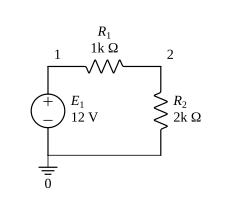

In [3]:
c1 = '''
e1,1,0,12
r1,1,2,1'k
r2,2,0,2'k
'''
draw(c1)

In [4]:
r1 = dc(c1)
r1

Result(domain='dc')
  i_e1 = -1/250
  i_r1 = 1/250
  i_r2 = 1/250
  p_e1 = -6/125
  p_r1 = 2/125
  p_r2 = 4/125
  r_e1 = 3000
  v_1 = 12
  v_2 = 8
  v_e1 = 12
  v_r1 = 4
  v_r2 = 8

### 2. Values

A value is a number, a symbol, or an expression in either. Here is the
divider again with its source left as a symbol we call `vs`, and beside it
a second source, `e2`, driving a 2 kΩ resistor, whose value is five times
the voltage at the divider's midpoint:

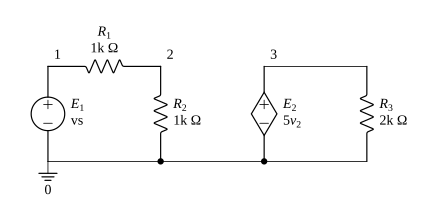

In [5]:
c2 = '''
e1,1,0,vs
r1,1,2,1'k
r2,2,0,1'k
e2,3,0,5*v2
r3,3,0,2'k
'''
draw(c2)

In [6]:
r2 = dc(c2)
r2

Result(domain='dc')
  i_e1 = -vs/2000
  i_e2 = -vs/800
  i_r1 = vs/2000
  i_r2 = vs/2000
  i_r3 = vs/800
  p_e1 = -vs**2/2000
  p_e2 = -vs**2/320
  p_r1 = vs**2/4000
  p_r2 = vs**2/4000
  p_r3 = vs**2/320
  r_e1 = 2000
  r_e2 = 2000
  v_1 = vs
  v_2 = vs/2
  v_3 = 5*vs/2
  v_e1 = vs
  v_e2 = 5*vs/2
  v_r1 = vs/2
  v_r2 = vs/2
  v_r3 = 5*vs/2

### 3. Brackets

**A parallel group, in a resistor's value only.** `[r1,r2,r3]` is those three
in parallel. Three resistors of 1 kΩ, 2 kΩ and 2 kΩ side by side between
node 1 and ground, written as one element we call `rp`:

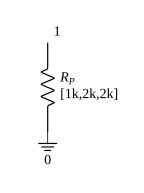

In [7]:
c3 = '''
rp,1,0,[1'k,2'k,2'k]
'''
draw(c3)

*This fence shows the bracket notation on its own, so with no source in the circuit every answer is zero. The Manual's parallel-shorthand example, further on, puts the same element across a 9 V source.*

In [8]:
r3 = dc(c3)
r3

Result(domain='dc')
  i_rp = 0
  p_rp = 0
  v_1 = 0
  v_rp = 0

### 4. Brackets

**A pair of terminals**, for a transformer or a two-port, when neither side
sits on ground. `[top,bottom]`. Here a two-port block, `z1`, sits between a
source and a load with neither of its ports touching ground; we call its
four terminals **a**, **b**, **c** and **d**, top before bottom on each
side:

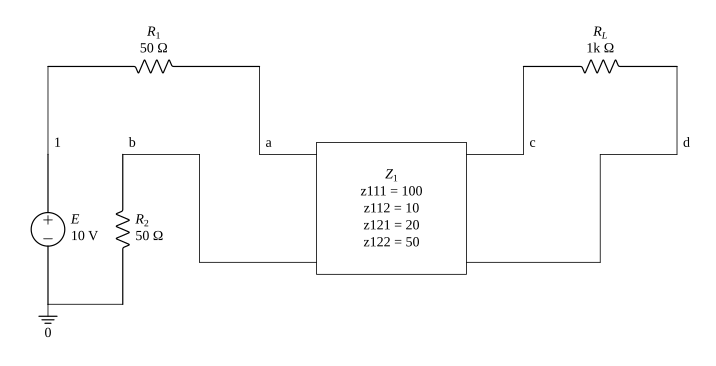

In [9]:
c4 = '''
e,1,0,10
r1,1,a,50
r2,b,0,50
z1,[a,b],[c,d],[100,10,20,50]
rl,c,d,1'k
'''
draw(c4)

In [10]:
r4 = dc(c4)
r4

Result(domain='dc')
  i_e = -105/2098
  i_r1 = 105/2098
  i_r2 = 105/2098
  i_rl = 1/1049
  i_z1a = 105/2098
  i_z1b = -105/2098
  i_z1c = -1/1049
  i_z1d = 1/1049
  p_e = -525/1049
  p_r1 = 275625/2200802
  p_r2 = 275625/2200802
  p_rl = 1000/1100401
  r_e = 4196/21
  v_1 = 10
  v_a = 7865/1049
  v_b = 2625/1049
  v_c = 1000/1049
  v_d = 0
  v_e = 10
  v_r1 = 2625/1049
  v_r2 = 2625/1049
  v_rl = 1000/1049
  note: Node(s) d, c have no path to node 0 (they lie behind a port or a coupling), so their voltages are measured against d, taken as 0.

## Running it, and reading the answer

[Read the chapter](https://learn.symbulator.com/9/manual-answers)

### 5. Running it, and reading the answer

The divider of the last chapter, the 12 V source across 1 kΩ and 2 kΩ in
series, described as before:

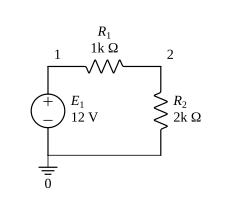

In [11]:
c5 = '''
e1,1,0,12
r1,1,2,1'k
r2,2,0,2'k
'''
draw(c5)

Set **Analysis** to *DC — direct current* and press
**Run Symbulator**. It comes back as two node voltages and three
answers per element; three of them:

In [12]:
r5 = dc(c5)
r5

Result(domain='dc')
  i_e1 = -1/250
  i_r1 = 1/250
  i_r2 = 1/250
  p_e1 = -6/125
  p_r1 = 2/125
  p_r2 = 4/125
  r_e1 = 3000
  v_1 = 12
  v_2 = 8
  v_e1 = 12
  v_r1 = 4
  v_r2 = 8

In [13]:
evaluate(r5, 'v2')

8

In [14]:
evaluate(r5, 'ir1')

1/250

In [15]:
evaluate(r5, 'pr1')

2/125

**The Manual prints**

**voltage at node 2**

$$v_{2} = 8\,\mathrm{V}$$

**current through r1**

$$i_{r1} = \dfrac{1}{250}\,\mathrm{A}$$

**power consumed by r1**

$$p_{r1} = \dfrac{2}{125}\,\mathrm{W}$$

## Symbols, Define and Expert Mode

[Read the chapter](https://learn.symbulator.com/9/manual-symbols)

### 6. Symbols, Define and Expert Mode

A divider with no values at all: a source and two resistors in series,
every value left as a symbol. We name the symbols `vs`, `ra` and `rb`, and
the elements `e`, `r1` and `r2`:

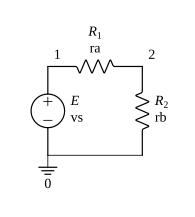

In [16]:
c6 = '''
e,1,0,vs
r1,1,2,ra
r2,2,0,rb
'''
draw(c6)

Run in DC, the voltage across the second resistor comes back as

In [17]:
r6 = dc(c6)
r6

Result(domain='dc')
  i_e = -vs/(ra + rb)
  i_r1 = vs/(ra + rb)
  i_r2 = vs/(ra + rb)
  p_e = -vs**2/(ra + rb)
  p_r1 = ra*vs**2/(ra + rb)**2
  p_r2 = rb*vs**2/(ra + rb)**2
  r_e = ra + rb
  v_1 = vs
  v_2 = rb*vs/(ra + rb)
  v_e = vs
  v_r1 = ra*vs/(ra + rb)
  v_r2 = rb*vs/(ra + rb)

In [18]:
evaluate(r6, 'vr2')

rb*vs/(ra + rb)

**The Manual prints**

**voltage drop across r2**

$$v_{r2} = \dfrac{rb\,vs}{ra + rb}$$

Run the same circuit again and the same answer now reads

The Define card, one per line:

```
ra = 4'k
rb = 6'k
vs = 10
```

In the package a Define is a condition -- the calculator's `|` -- applied to the whole system.

In [19]:
r7 = dc(c6, conditions=["ra = 4'k", "rb = 6'k", 'vs = 10'])
r7

Result(domain='dc')
  i_e = -1/1000
  i_r1 = 1/1000
  i_r2 = 1/1000
  p_e = -1/100
  p_r1 = 1/250
  p_r2 = 3/500
  r_e = 10000
  v_1 = 10
  v_2 = 6
  v_e = 10
  v_r1 = 4
  v_r2 = 6

In [20]:
evaluate(r7, 'vr2')

6

**The Manual prints**

**voltage drop across r2**

$$v_{r2} = 6\,\mathrm{V}$$

## Sources, conductances and shorthands

[Read the chapter](https://learn.symbulator.com/9/manual-dc)

### 7. Current sources

A 3 mA source feeding two resistors in parallel, one of them given not as
a resistance but as a conductance $g$. We write the source with its arrow
pointing into node 1, `j,0,1`, name the resistors `r1` and `r2`, and give
the first the value `1/g`, since there is no conductance element and a
conductance is a resistance written as its reciprocal:

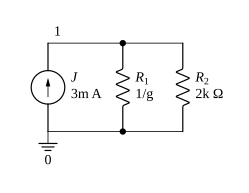

In [21]:
c7 = '''
j,0,1,3'm
r1,1,0,1/g
r2,1,0,2'k
'''
draw(c7)

Run in DC, the voltage across the pair comes back in terms of that
conductance:

In [22]:
r8 = dc(c7)
r8

Result(domain='dc')
  i_j = 3/1000
  i_r1 = 6*g/(2000*g + 1)
  i_r2 = 3/(1000*(2000*g + 1))
  p_j = -9/(1000000*g + 500)
  p_r1 = 36*g/(2000*g + 1)**2
  p_r2 = 9/(500*(2000*g + 1)**2)
  r_j = 2000/(2000*g + 1)
  v_1 = 6/(2000*g + 1)
  v_j = -6/(2000*g + 1)
  v_r1 = 6/(2000*g + 1)
  v_r2 = 6/(2000*g + 1)

In [23]:
evaluate(r8, 'vr1')

6/(2000*g + 1)

**The Manual prints**

**voltage drop across r1**

$$v_{r1} = \dfrac{6}{2000 g + 1}$$

### 8. The parallel shorthand

In a **resistor's value only**, a bracketed list is that group in parallel.
A 9 V source across three resistors of 1 kΩ, 2 kΩ and 2 kΩ side by side,
the three written as one element we call `rp`:

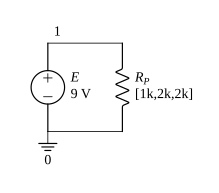

In [24]:
c8 = '''
e,1,0,9
rp,1,0,[1'k,2'k,2'k]
'''
draw(c8)

Run in DC, the current through the group is

In [25]:
r9 = dc(c8)
r9

Result(domain='dc')
  i_e = -9/500
  i_rp = 9/500
  p_e = -81/500
  p_rp = 81/500
  r_e = 500
  v_1 = 9
  v_e = 9
  v_rp = 9

In [26]:
evaluate(r9, 'irp')

9/500

**The Manual prints**

**current through rp**

$$i_{rp} = \dfrac{9}{500}\,\mathrm{A}$$

## Equivalents and the load question

[Read the chapter](https://learn.symbulator.com/9/manual-equivalents)

### 9. Equivalent resistance

Three resistors and no source: a 100 Ω in series with a 200 Ω and a 300 Ω
in parallel, and the question is the resistance of the whole seen from its
two ends. We name them `r1` to `r3`, call the free end node **1** and the
junction node **2**, and put the far end on ground:

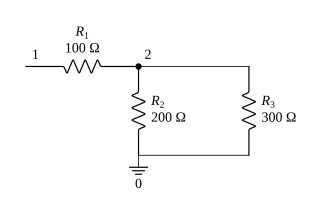

In [27]:
c9 = '''
r1,1,2,100
r2,2,0,200
r3,2,0,300
'''
draw(c9)

Open **Find equivalent**, choose *Resistance / impedance*, and give
the two nodes **1** and **0**:

In [28]:
r10 = er(c9, '1', '0', domain='dc')
r10

220

In [29]:
evaluate({'req': r10}, 'req')

220

**The Manual prints**

**equivalent resistance**

$$R_{eq} = 220\,\Omega$$

### 10. Thévenin and Norton

A 20 V source and a divider of 50 Ω and 150 Ω, and the question is what
the circuit looks like from the divider's midpoint: a single source behind
a single resistance. We describe the three elements, naming them `e`, `r1`
and `r2`, and call the midpoint node **2**:

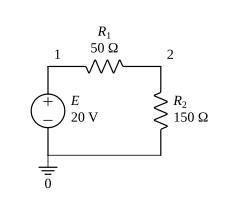

In [30]:
c10 = '''
e,1,0,20
r1,1,2,50
r2,2,0,150
'''
draw(c10)

Open **Find equivalent**, choose *Thévenin / Norton*, and give the two
terminals **2** and **0**:

In [31]:
r11 = th(c10, '2', '0', domain='dc')
r11

TheveninResult(domain='dc', vth=15, ino=2/5, req=75/2, pmax=3/2)

In [32]:
evaluate(r11, 'vth')

15

In [33]:
evaluate(r11, 'req')

75/2

In [34]:
evaluate(r11, 'ino')

2/5

In [35]:
evaluate(r11, 'pmax')

3/2

**The Manual prints**

**Thévenin voltage**

$$v_{th} = 15\,\mathrm{V}$$

**equivalent resistance**

$$R_{eq} = \dfrac{75}{2}\,\Omega$$

**Norton current**

$$i_{no} = \dfrac{2}{5}\,\mathrm{A}$$

**maximum deliverable power**

$$p_{max} = \dfrac{3}{2}\,\mathrm{W}$$

## Operational amplifiers

[Read the chapter](https://learn.symbulator.com/9/manual-opamps)

### 11. Operational amplifiers

An inverting amplifier: a 2 V source into the op amp's inverting input
through 10 kΩ, a 47 kΩ resistor feeding the output back to that input, and
the non-inverting input on ground. We name the source `e` and the
resistors `r1` and `r2`, call the summing junction **m** and the output
**o**, and write the op amp's three nodes in the order the element wants,
non-inverting input first:

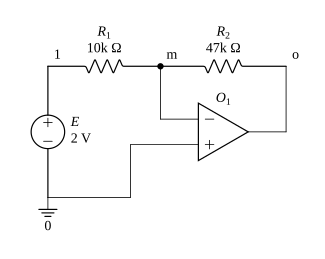

In [36]:
c11 = '''
e,1,0,2
r1,1,m,10'k
r2,m,o,47'k
o1,0,m,o
'''
draw(c11)

Run in DC, the output is

In [37]:
r12 = dc(c11)
r12

Result(domain='dc')
  i_e = -1/5000
  i_o1 = -1/5000
  i_r1 = 1/5000
  i_r2 = 1/5000
  p_e = -1/2500
  p_o1 = -47/25000
  p_r1 = 1/2500
  p_r2 = 47/25000
  r_e = 10000
  v_1 = 2
  v_e = 2
  v_m = 0
  v_o = -47/5
  v_r1 = 2
  v_r2 = 47/5

In [38]:
evaluate(r12, 'vo')

-47/5

**The Manual prints**

**voltage at node o**

$$v_{o} = -\dfrac{47}{5}\,\mathrm{V}$$

### 12. When ideal is not enough

There is no finite-gain op amp element. Model one as a dependent source,
which is what a finite-gain op amp is. The same amplifier, with the `o`
element replaced by a voltage source we call `ea`, driving the output node
with 100,000 times the voltage between the two inputs — the non-inverting
one, at ground, minus the inverting one at **m**:

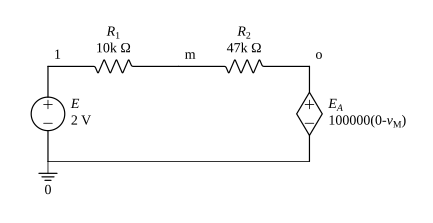

In [39]:
c12 = '''
e,1,0,2
r1,1,m,10'k
r2,m,o,47'k
ea,o,0,100000*(0-vm)
'''
draw(c12)

Run in DC, the output is now

In [40]:
r13 = dc(c12)
r13

Result(domain='dc')
  i_e = -100001/500028500
  i_ea = 100001/500028500
  i_r1 = 100001/500028500
  i_r2 = 100001/500028500
  p_e = -100001/250014250
  p_ea = -1880018800/1000114003249
  p_r1 = 10000200001/25002850081225
  p_r2 = 470009400047/250028500812250
  r_e = 1000057000/100001
  r_ea = 4700000000/100001
  v_1 = 2
  v_e = 2
  v_ea = -9400000/1000057
  v_m = 94/1000057
  v_o = -9400000/1000057
  v_r1 = 2000020/1000057
  v_r2 = 9400094/1000057

In [41]:
evaluate(r13, 'vo')

-9400000/1000057

**The Manual prints**

**voltage at node o**

$$v_{o} = -\dfrac{9400000}{1000057}\,\mathrm{V}$$

## Capacitors, inductors and TR

[Read the chapter](https://learn.symbulator.com/9/manual-transients)

### 13. TR

A 10 V source charging a 1 µF capacitor through a 1 kΩ resistor, with
nothing stored in the capacitor to begin with. In TR a source with a plain
numerical value is a step that begins at $t$ = 0, so this is the source
switched on at that instant. We name the three elements `e`, `r` and `c`,
and write the capacitor with no fifth field:

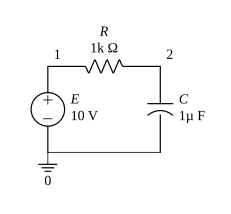

In [42]:
c13 = '''
e,1,0,10
r,1,2,1'k
c,2,0,1'u
'''
draw(c13)

Set **Analysis** to *TR — transient / time domain* and run:

In [43]:
r14 = tr(c13)
r14

Result(domain='tr')
  i_c = exp(-1000*t)/100
  i_e = -exp(-1000*t)/100
  i_r = exp(-1000*t)/100
  v_1 = 10
  v_2 = 10 - 10*exp(-1000*t)

In [44]:
r14["v_2"]  # vc: node 2 minus ground

10 - 10*exp(-1000*t)

**The Manual prints**

**voltage drop across c**

$$v_{c} = 10 - 10\,e^{-1000\,t}$$

### 14. TR

Give the capacitor a starting voltage, 4 V in its fifth field, and run
again:

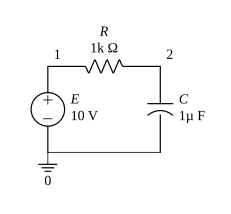

In [45]:
c14 = '''
e,1,0,10
r,1,2,1'k
c,2,0,1'u,4
'''
draw(c14)

In [46]:
r15 = tr(c14)
r15

Result(domain='tr')
  i_c = 3*exp(-1000*t)/500
  i_e = -3*exp(-1000*t)/500
  i_r = 3*exp(-1000*t)/500
  v_1 = 10
  v_2 = 10 - 6*exp(-1000*t)

In [47]:
r15["v_2"]  # vc: node 2 minus ground

10 - 6*exp(-1000*t)

**The Manual prints**

**voltage drop across c**

$$v_{c} = 10 - 6\,e^{-1000\,t}$$

### 15. No source at all

A natural response needs no source — the energy is already in the element.
A capacitor charged to 10 V and left across a 1 kΩ resistor:

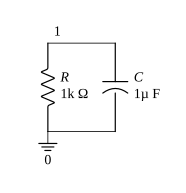

In [48]:
c15 = '''
r,1,0,1'k
c,1,0,1'u,10
'''
draw(c15)

Run in TR:

In [49]:
r16 = tr(c15)
r16

Result(domain='tr')
  i_c = -exp(-1000*t)/100
  i_r = exp(-1000*t)/100
  v_1 = 10*exp(-1000*t)

In [50]:
r16["v_1"]  # vc: node 1 minus ground

10*exp(-1000*t)

**The Manual prints**

**voltage drop across c**

$$v_{c} = 10\,e^{-1000\,t}$$

## AC, phasors and power

[Read the chapter](https://learn.symbulator.com/9/manual-ac)

### 16. AC, phasors and power

A 10 V source driving a 50 Ω resistor and a 50 mH inductor in series, at
1000 rad/s. We name the three `e`, `r` and `l`, and write the inductor as
its inductance:

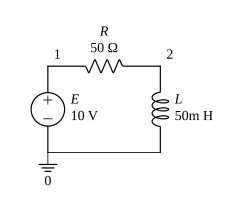

In [51]:
c16 = '''
e,1,0,10
r,1,2,50
l,2,0,0.05
'''
draw(c16)

Set **Analysis** to *AC — alternating current*, put **1000** in the
**ω — angular frequency** box, and run. At that frequency the inductor
is 50 Ω of reactance, so the loop's impedance is 50 + 50j, and the answers
say so:

In [52]:
r17 = ac(c16, omega=1000)
r17

Result(domain='ac')
  ap_e = -0.500000000000000
  ap_r = 0.500000000000000
  i_e = -0.1 + 0.1*I
  i_l = 0.1 - 0.1*I
  i_r = 0.1 - 0.1*I
  p_e = -0.500000000000000
  p_r = 0.500000000000000
  q_e = -0.500000000000000
  q_r = 0
  s_e = -0.5 - 0.5*I
  s_l = 0.5*I
  s_r = 0.500000000000000
  v_1 = 10.0000000000000
  v_2 = 5.0 + 5.0*I
  v_e = 10.0000000000000
  v_l = 5.0 + 5.0*I
  v_r = 5.0 - 5.0*I
  z_e = 50.0 + 50.0*I

In [53]:
evaluate(r17, 'ir')

0.1 - 0.1*I

In [54]:
evaluate(r17, 'vl')

5.0 + 5.0*I

**The Manual prints**

**current through r**

$$i_{r} = 0.1 - 0.1\text{j}\,\mathrm{A}$$

**voltage drop across l**

$$v_{l} = 5.0 + 5.0\text{j}\,\mathrm{V}$$

### 17. The four power answers

The same shape with a 30 Ω resistor and a 40 mH inductor, at 1000 rad/s
again, so that the impedance is 30 + 40j, a 3-4-5 triangle:

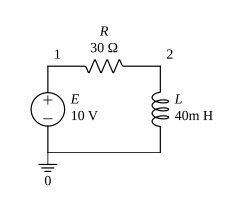

In [55]:
c17 = '''
e,1,0,10
r,1,2,30
l,2,0,0.04
'''
draw(c17)

Run in AC at ω = 1000, the source's card reads

In [56]:
r18 = ac(c17, omega=1000)
r18

Result(domain='ac')
  ap_e = -0.600000000000000
  ap_r = 0.600000000000000
  i_e = -0.12 + 0.16*I
  i_l = 0.12 - 0.16*I
  i_r = 0.12 - 0.16*I
  p_e = -0.600000000000000
  p_r = 0.600000000000000
  q_e = -0.800000000000000
  q_r = 0
  s_e = -0.6 - 0.8*I
  s_l = 0.8*I
  s_r = 0.600000000000000
  v_1 = 10.0000000000000
  v_2 = 6.4 + 4.8*I
  v_e = 10.0000000000000
  v_l = 6.4 + 4.8*I
  v_r = 3.6 - 4.8*I
  z_e = 30.0 + 40.0*I

In [57]:
evaluate(r18, '-se')

0.6 + 0.8*I

**The Manual prints**

**complex power delivered by e**

$$-s_{e} = 0.6 + 0.8\text{j}\,\mathrm{VA}$$

## Mutual inductance and transformers

[Read the chapter](https://learn.symbulator.com/9/manual-coupling)

### 18. The dots are the node order

Two 30 mH coils coupled by 10 mH, the first across a 10 V source and the
second across a 30 Ω load, at 1000 rad/s. We name the coils `l1` and `l2`
and the load `r2`, and we write each coil's dotted end first, node 1 for
the primary and node 2 for the secondary:

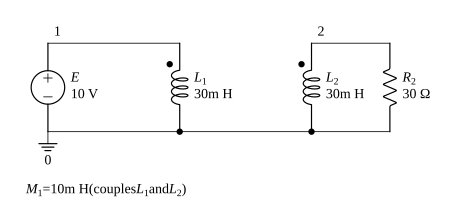

In [58]:
c18 = '''
e,1,0,10
l1,1,0,0.03
l2,2,0,0.03
m1,l1,l2,0.01
r2,2,0,30
'''
draw(c18)

Run in AC at ω = 1000, the current in the load is

In [59]:
r19 = ac(c18, omega=1000)
r19

Result(domain='ac')
  ap_e = -0.103448275862069
  ap_r2 = 0.103448275862069
  i_e = -0.0206896551724138 + 0.351724137931034*I
  i_l1 = 0.0206896551724138 - 0.351724137931034*I
  i_l2 = -0.0620689655172414 + 0.0551724137931034*I
  i_r2 = 0.0620689655172414 - 0.0551724137931034*I
  p_e = -0.103448275862069
  p_r2 = 0.103448275862069
  q_e = -1.75862068965517
  q_r2 = 0
  s_e = -0.103448275862069 - 1.75862068965517*I
  s_l1 = 0.103448275862069 + 1.75862068965517*I
  s_l2 = -0.103448275862069
  s_r2 = 0.103448275862069
  v_1 = 10.0000000000000
  v_2 = 1.86206896551724 - 1.6551724137931*I
  v_e = 10.0000000000000
  v_l1 = 10.0000000000000
  v_l2 = 1.86206896551724 - 1.6551724137931*I
  v_r2 = 1.86206896551724 - 1.6551724137931*I
  z_e = 1.66666666666667 + 28.3333333333333*I

In [60]:
evaluate(r19, 'ir2')

0.0620689655172414 - 0.0551724137931034*I

**The Manual prints**

**current through r2**

$$i_{r2} = 0.0621 - 0.0552\text{j}\,\mathrm{A}$$

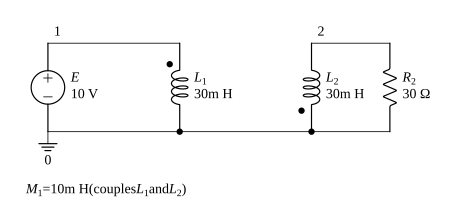

In [61]:
c19 = '''
e,1,0,10
l1,1,0,0.03
l2,0,2,0.03
m1,l1,l2,0.01
r2,2,0,30
'''
draw(c19)

Now write the second coil the other way round, `l2,0,2,0.03`, the same
coil with its dot at the other end, and run again:

In [62]:
r20 = ac(c19, omega=1000)
r20

Result(domain='ac')
  ap_e = -0.103448275862069
  ap_r2 = 0.103448275862069
  i_e = -0.0206896551724138 + 0.351724137931034*I
  i_l1 = 0.0206896551724138 - 0.351724137931034*I
  i_l2 = -0.0620689655172414 + 0.0551724137931034*I
  i_r2 = -0.0620689655172414 + 0.0551724137931034*I
  p_e = -0.103448275862069
  p_r2 = 0.103448275862069
  q_e = -1.75862068965517
  q_r2 = 0
  s_e = -0.103448275862069 - 1.75862068965517*I
  s_l1 = 0.103448275862069 + 1.75862068965517*I
  s_l2 = -0.103448275862069
  s_r2 = 0.103448275862069
  v_1 = 10.0000000000000
  v_2 = -1.86206896551724 + 1.6551724137931*I
  v_e = 10.0000000000000
  v_l1 = 10.0000000000000
  v_l2 = 1.86206896551724 - 1.6551724137931*I
  v_r2 = -1.86206896551724 + 1.6551724137931*I
  z_e = 1.66666666666667 + 28.3333333333333*I

In [63]:
evaluate(r20, 'ir2')

-0.0620689655172414 + 0.0551724137931034*I

**The Manual prints**

**current through r2**

$$i_{r2} = -0.0621 + 0.0552\text{j}\,\mathrm{A}$$

### 19. t — the ideal transformer

The two-node form names the top terminal of each side and grounds the other
two. A 120 V source on the primary, a 5 Ω load on the secondary, ten turns
to one; we name the transformer `t1` and the load `rl`, and call the two
tops node **1** and node **2**:

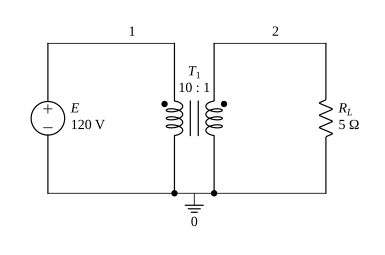

In [64]:
c20 = '''
e,1,0,120
t1,1,2,10,1
rl,2,0,5
'''
draw(c20)

Run in DC, the load's voltage and current are

In [65]:
r21 = dc(c20)
r21

Result(domain='dc')
  i_e = -6/25
  i_rl = 12/5
  i_t11 = 6/25
  i_t12 = -12/5
  p_e = -144/5
  p_rl = 144/5
  r_e = 500
  v_1 = 120
  v_2 = 12
  v_e = 120
  v_rl = 12

In [66]:
evaluate(r21, 'vrl')

12

In [67]:
evaluate(r21, 'irl')

12/5

**The Manual prints**

**voltage drop across rl**

$$v_{rl} = 12\,\mathrm{V}$$

**current through rl**

$$i_{rl} = \dfrac{12}{5}\,\mathrm{A}$$

## The s-domain, transfer functions and plots

[Read the chapter](https://learn.symbulator.com/9/manual-frequency)

### 20. FD

The RC circuit of *Capacitors, inductors and TR* with its source left as a
symbol we call `vs`, a 1 kΩ resistor and a 1 µF capacitor:

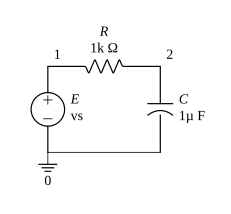

In [68]:
c21 = '''
e,1,0,vs
r,1,2,1'k
c,2,0,1'u
'''
draw(c21)

Set **Analysis** to *FD — complex frequency domain* and run:

In [69]:
r22 = fd(c21)
r22

Result(domain='fd')
  i_c = s*vs/(1000*(s + 1000))
  i_e = -s*vs/(1000*s + 1000000)
  i_r = s*vs/(1000*(s + 1000))
  v_1 = vs
  v_2 = 1000*vs/(s + 1000)

In [70]:
r22["v_2"]  # vc: node 2 minus ground

1000*vs/(s + 1000)

**The Manual prints**

**voltage drop across c**

$$v_{c} = \dfrac{1000\,vs}{s + 1000}$$

## Two-ports

[Read the chapter](https://learn.symbulator.com/9/manual-twoports)

### 21. Finding the parameters

A T of three resistors, 10 Ω and 30 Ω along the top and 20 Ω down the
middle, seen as a two-port with one port at each end. We name the three
`ra`, `rb` and `rc`, call the two ends node **1** and node **3** and the
middle node **2**, and put the bottom rail on ground:

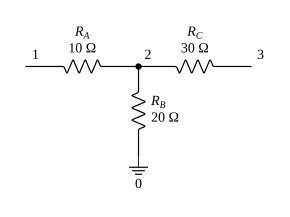

In [71]:
c22 = '''
ra,1,2,10
rb,2,0,20
rc,2,3,30
'''
draw(c22)

Open **Find equivalent**, choose *Two-port parameters*, set the kind
to **z**, and give the ports as **1** and **3**:

In [72]:
r23 = port(c22, '1', '3', 'z', domain='dc')
r23

PortResult('z', 11=30, 12=20, 21=20, 22=50)

In [73]:
evaluate(r23, 'z11')

30

In [74]:
evaluate(r23, 'z12')

20

In [75]:
evaluate(r23, 'z21')

20

In [76]:
evaluate(r23, 'z22')

50

**The Manual prints**

**open-circuit input impedance**

$$z_{11} = 30\,\Omega$$

**open-circuit reverse transfer impedance**

$$z_{12} = 20\,\Omega$$

**open-circuit forward transfer impedance**

$$z_{21} = 20\,\Omega$$

**open-circuit output impedance**

$$z_{22} = 50\,\Omega$$

### 22. A two-port as an element

The same six letters are element types. Give the block its four parameters
in brackets and it behaves as that two-port. A block known only by its z
parameters, between a source with 50 Ω in series and a 1 kΩ load; we name
the block `z1` and call its two ports **a** and **b**:

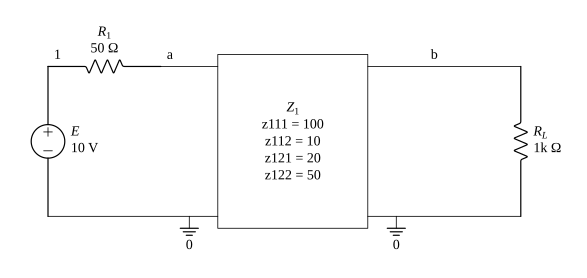

In [77]:
c23 = '''
e,1,0,10
r1,1,a,50
z1,a,b,[100,10,20,50]
rl,b,0,1'k
'''
draw(c23)

In [78]:
r24 = dc(c23)
r24

Result(domain='dc')
  i_e = -105/1573
  i_r1 = 105/1573
  i_rl = 2/1573
  i_z1a = 105/1573
  i_z1b = -2/1573
  p_e = -1050/1573
  p_r1 = 551250/2474329
  p_rl = 4000/2474329
  r_e = 3146/21
  v_1 = 10
  v_a = 10480/1573
  v_b = 2000/1573
  v_e = 10
  v_r1 = 5250/1573
  v_rl = 2000/1573

## Where next

* The Manual: https://learn.symbulator.com/9/
* The Manual as a PDF: https://learn.symbulator.com/symbulator-manual.pdf
* The Course's problems, one notebook per book, and *A Baker's Dozen*, are beside this file.